<a href="https://colab.research.google.com/github/vani-max/CNN_Model_Project/blob/main/AIStudio2A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage 2A — Mini Technical Challenge : CNN on CIFAR-10 Dataset**

In [ ]:
import tensorflow as tf, keras
from tensorflow.keras import datasets, layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np

# **Dataset Overview**

In [ ]:
(X_train,y_train) , (X_test, y_test)=  datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [ ]:
classes[1]

'automobile'

In [ ]:
def show(X,y,index):
  plt.figure(figsize=(15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

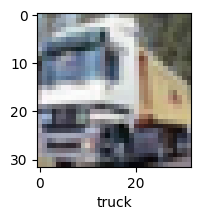

In [ ]:
show(X_train,y_train,1)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
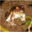

In [ ]:
X_train[0]

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

# **Baseline Model: Artificial Neural Network (ANN)**

In [ ]:
model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation='relu'),
    layers.Dense(1000,activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1182 - loss: 2.3553


[2.355246067047119, 0.11219999939203262]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = model.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
              precision    recall  f1-score   support

           0       0.27      0.01      0.02      1000
           1       0.10      0.03      0.04      1000
           2       0.00      0.00      0.00      1000
           3       0.67      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.13      0.00      0.01      1000
           6       0.11      0.37      0.17      1000
           7       0.00      0.00      0.00      1000
           8       0.03      0.03      0.03      1000
           9       0.13      0.68      0.22      1000

    accuracy                           0.11     10000
   macro avg       0.14      0.11      0.05     10000
weighted avg       0.14      0.11      0.05     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **CNN Model Architecture**

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

**CNN without dropout - Primary Model**

In [ ]:
cnn_base = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_base = cnn_base.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

cnn_base.evaluate(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 52ms/step - accuracy: 0.3552 - loss: 1.7543 - val_accuracy: 0.5580 - val_loss: 1.2609
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 47ms/step - accuracy: 0.5824 - loss: 1.1959 - val_accuracy: 0.6201 - val_loss: 1.0929
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.6440 - loss: 1.0186 - val_accuracy: 0.6365 - val_loss: 1.0543
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - accuracy: 0.6794 - loss: 0.9227 - val_accuracy: 0.6638 - val_loss: 0.9750
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.6985 - loss: 0.8646 - val_accuracy: 0.6576 - val_loss: 0.9888
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.7240 - loss: 0.7892 - val_accuracy: 0.6754 - val_loss: 0.9564
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.7393 - loss: 0.7458 - val_accuracy: 0.6802 - val_loss: 0.9424
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7578 -

[0.9696363210678101, 0.6851999759674072]

CNN With dropout - Experiment

In [ ]:
cnn = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = cnn.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.2465 - loss: 1.9902 - val_accuracy: 0.4641 - val_loss: 1.5120
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.4168 - loss: 1.5724 - val_accuracy: 0.5551 - val_loss: 1.2698
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.4865 - loss: 1.4112 - val_accuracy: 0.5816 - val_loss: 1.1783
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.5231 - loss: 1.3121 - val_accuracy: 0.6112 - val_loss: 1.1047
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.5519 - loss: 1.2481 - val_accuracy: 0.6088 - val_loss: 1.1119
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.5748 - loss: 1.1828 - val_accuracy: 0.6436 - val_loss: 1.0247
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.5894 - loss: 1.1424 - val_accuracy: 0.6152 - val_loss: 1.0846
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.5999 -

In [ ]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6610 - loss: 0.9702


[0.9771124720573425, 0.6636000275611877]

In [ ]:
y_test = y_test.reshape(-1,)

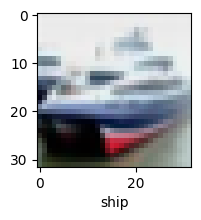

In [ ]:
show(X_test, y_test,1)

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


array([[1.08225280e-02, 4.09967545e-03, 1.40421186e-02, 6.00734651e-01,
        4.55287751e-03, 2.17214614e-01, 7.35074803e-02, 3.47203040e-03,
        6.29564524e-02, 8.59757978e-03],
       [7.99439941e-03, 3.02952789e-02, 1.65081371e-09, 5.92478422e-09,
        3.12242621e-10, 4.16933363e-11, 2.13625895e-09, 9.11268240e-13,
        9.61548269e-01, 1.61909367e-04],
       [1.84697613e-01, 1.61319554e-01, 4.44976264e-04, 5.55662613e-04,
        4.24624013e-04, 9.30779424e-05, 8.28718839e-05, 1.47982166e-04,
        5.36276996e-01, 1.15956604e-01],
       [6.39596403e-01, 6.27279887e-03, 7.09959422e-04, 9.87259191e-05,
        1.78556569e-04, 3.51126732e-06, 1.90262817e-05, 3.28901274e-06,
        3.51053119e-01, 2.06455658e-03],
       [5.65380105e-06, 1.69170980e-05, 1.21963462e-02, 2.33285385e-03,
        2.44165137e-02, 4.82656207e-04, 9.60540056e-01, 2.48717765e-06,
        5.57335989e-06, 8.07014942e-07]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [ ]:
classes[y_classes[1]]

'ship'

In [ ]:
print(classification_report(y_test, y_classes))

              precision    recall  f1-score   support

           0       0.68      0.75      0.71      1000
           1       0.83      0.79      0.81      1000
           2       0.56      0.48      0.52      1000
           3       0.50      0.43      0.47      1000
           4       0.54      0.61      0.57      1000
           5       0.63      0.48      0.55      1000
           6       0.65      0.84      0.74      1000
           7       0.76      0.66      0.71      1000
           8       0.72      0.82      0.77      1000
           9       0.73      0.78      0.76      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.66      0.66      0.66     10000



CNN without Dropout - Plots

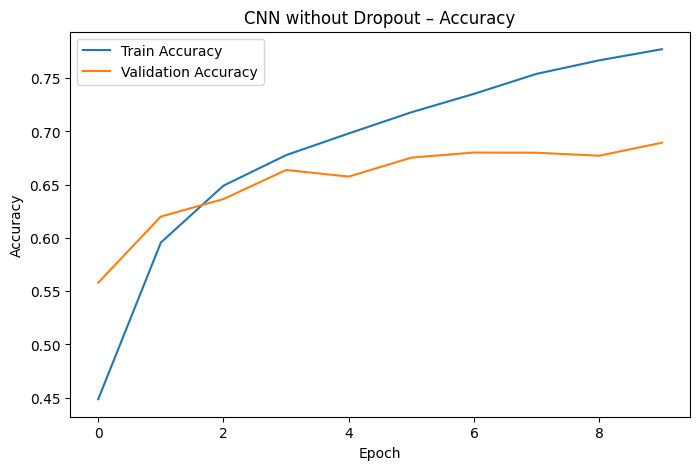

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN without Dropout – Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

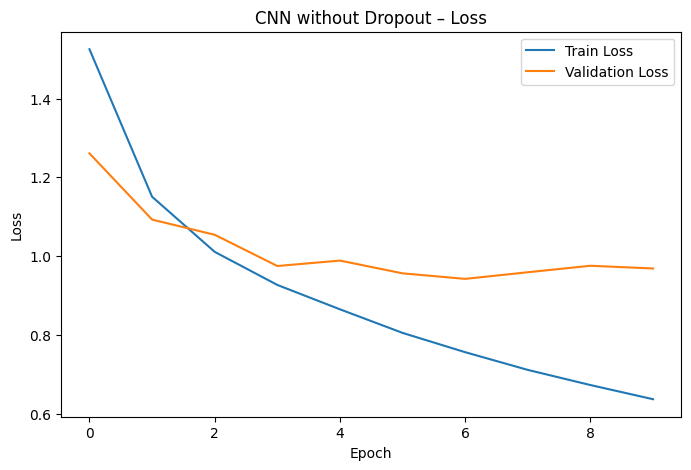

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('CNN without Dropout – Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Without Dropout, training accuracy increases faster than validation accuracy, indicating mild overfitting.

CNN With Dropout - Plot

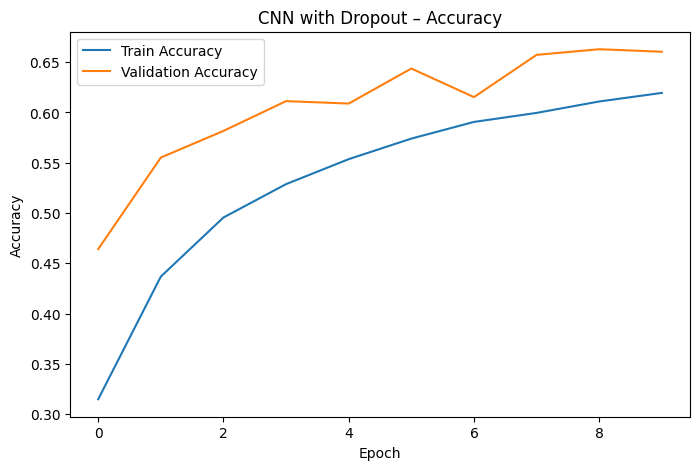

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN with Dropout – Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

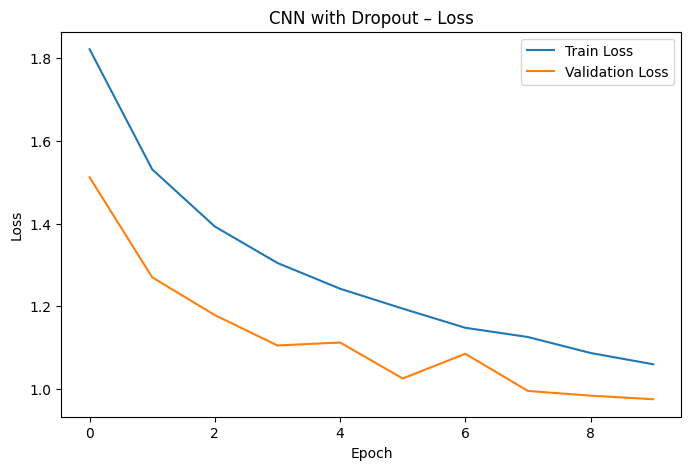

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN with Dropout – Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

With Dropout, training accuracy is lower but validation curves are smoother, suggesting improved generalization.

Final Insights and Learnings

This task was my first hands-on experience with convolutional neural networks and image classification. I began with a fully connected ANN as a baseline to understand how a simple model performs on image data. While the ANN was able to learn basic patterns, its performance was limited because it treats each pixel independently and cannot exploit spatial relationships.

Introducing a CNN led to a significant improvement in performance. Convolutional layers were able to learn spatial hierarchies such as edges and textures, which are crucial for image classification tasks like CIFAR-10.

I further experimented with Dropout to study its effect on generalization. Although the overall test accuracy dropped slightly (from ~68% to ~66.3%), the training and validation curves became more stable. This indicates reduced overfitting and highlights the trade-off between model capacity and robustness, especially when training for a limited number of epochs.

Overall, this exercise helped me understand that model selection, architecture choices, and regularization techniques can be as important as raw accuracy when building reliable real-world machine learning systems.